In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn import metrics
from sklearn.svm import SVC
from xgboost import XGBRegressor
from sklearn.linear_model import LinearRegression, Lasso, Ridge
from sklearn.ensemble import RandomForestRegressor

In [22]:
calories=pd.read_csv("calories.csv")
exercise=pd.read_csv("exercise.csv")

In [23]:
df=pd.concat([calories,exercise],axis=1)

In [24]:
df.head(5)

,User_ID,Calories,User_ID,Gender,Age,Height,Weight,Duration,Heart_Rate,Body_Temp
0,14733363,231.0,14733363,male,68,190.0,94.0,29.0,105.0,40.8
1,14861698,66.0,14861698,female,20,166.0,60.0,14.0,94.0,40.3
2,11179863,26.0,11179863,male,69,179.0,79.0,5.0,88.0,38.7
3,16180408,71.0,16180408,female,34,179.0,71.0,13.0,100.0,40.5
4,17771927,35.0,17771927,female,27,154.0,58.0,10.0,81.0,39.8


In [26]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   User_ID     15000 non-null  int64  
 1   Calories    15000 non-null  float64
 2   User_ID     15000 non-null  int64  
 3   Gender      15000 non-null  object 
 4   Age         15000 non-null  int64  
 5   Height      15000 non-null  float64
 6   Weight      15000 non-null  float64
 7   Duration    15000 non-null  float64
 8   Heart_Rate  15000 non-null  float64
 9   Body_Temp   15000 non-null  float64
dtypes: float64(6), int64(3), object(1)
memory usage: 1.1+ MB


In [28]:
df.shape

(15000, 10)

In [30]:
df.describe()

,User_ID,Calories,User_ID,Age,Height,Weight,Duration,Heart_Rate,Body_Temp
count,1.500000e+04,15000.000000,1.500000e+04,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000
mean,1.497736e+07,89.539533,1.497736e+07,42.789800,174.465133,74.966867,15.530600,95.518533,40.025453
std,2.872851e+06,62.456978,2.872851e+06,16.980264,14.258114,15.035657,8.319203,9.583328,0.779230
min,1.000116e+07,1.000000,1.000116e+07,20.000000,123.000000,36.000000,1.000000,67.000000,37.100000
25%,1.247419e+07,35.000000,1.247419e+07,28.000000,164.000000,63.000000,8.000000,88.000000,39.600000
50%,1.499728e+07,79.000000,1.499728e+07,39.000000,175.000000,74.000000,16.000000,96.000000,40.200000
75%,1.744928e+07,138.000000,1.744928e+07,56.000000,185.000000,87.000000,23.000000,103.000000,40.600000
max,1.999965e+07,314.000000,1.999965e+07,79.000000,222.000000,132.000000,30.000000,128.000000,41.500000


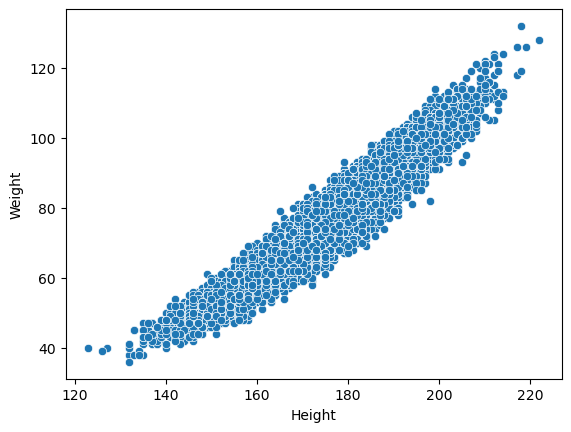

In [34]:
sns.scatterplot(x="Height",y="Weight",data=df)
plt.show()

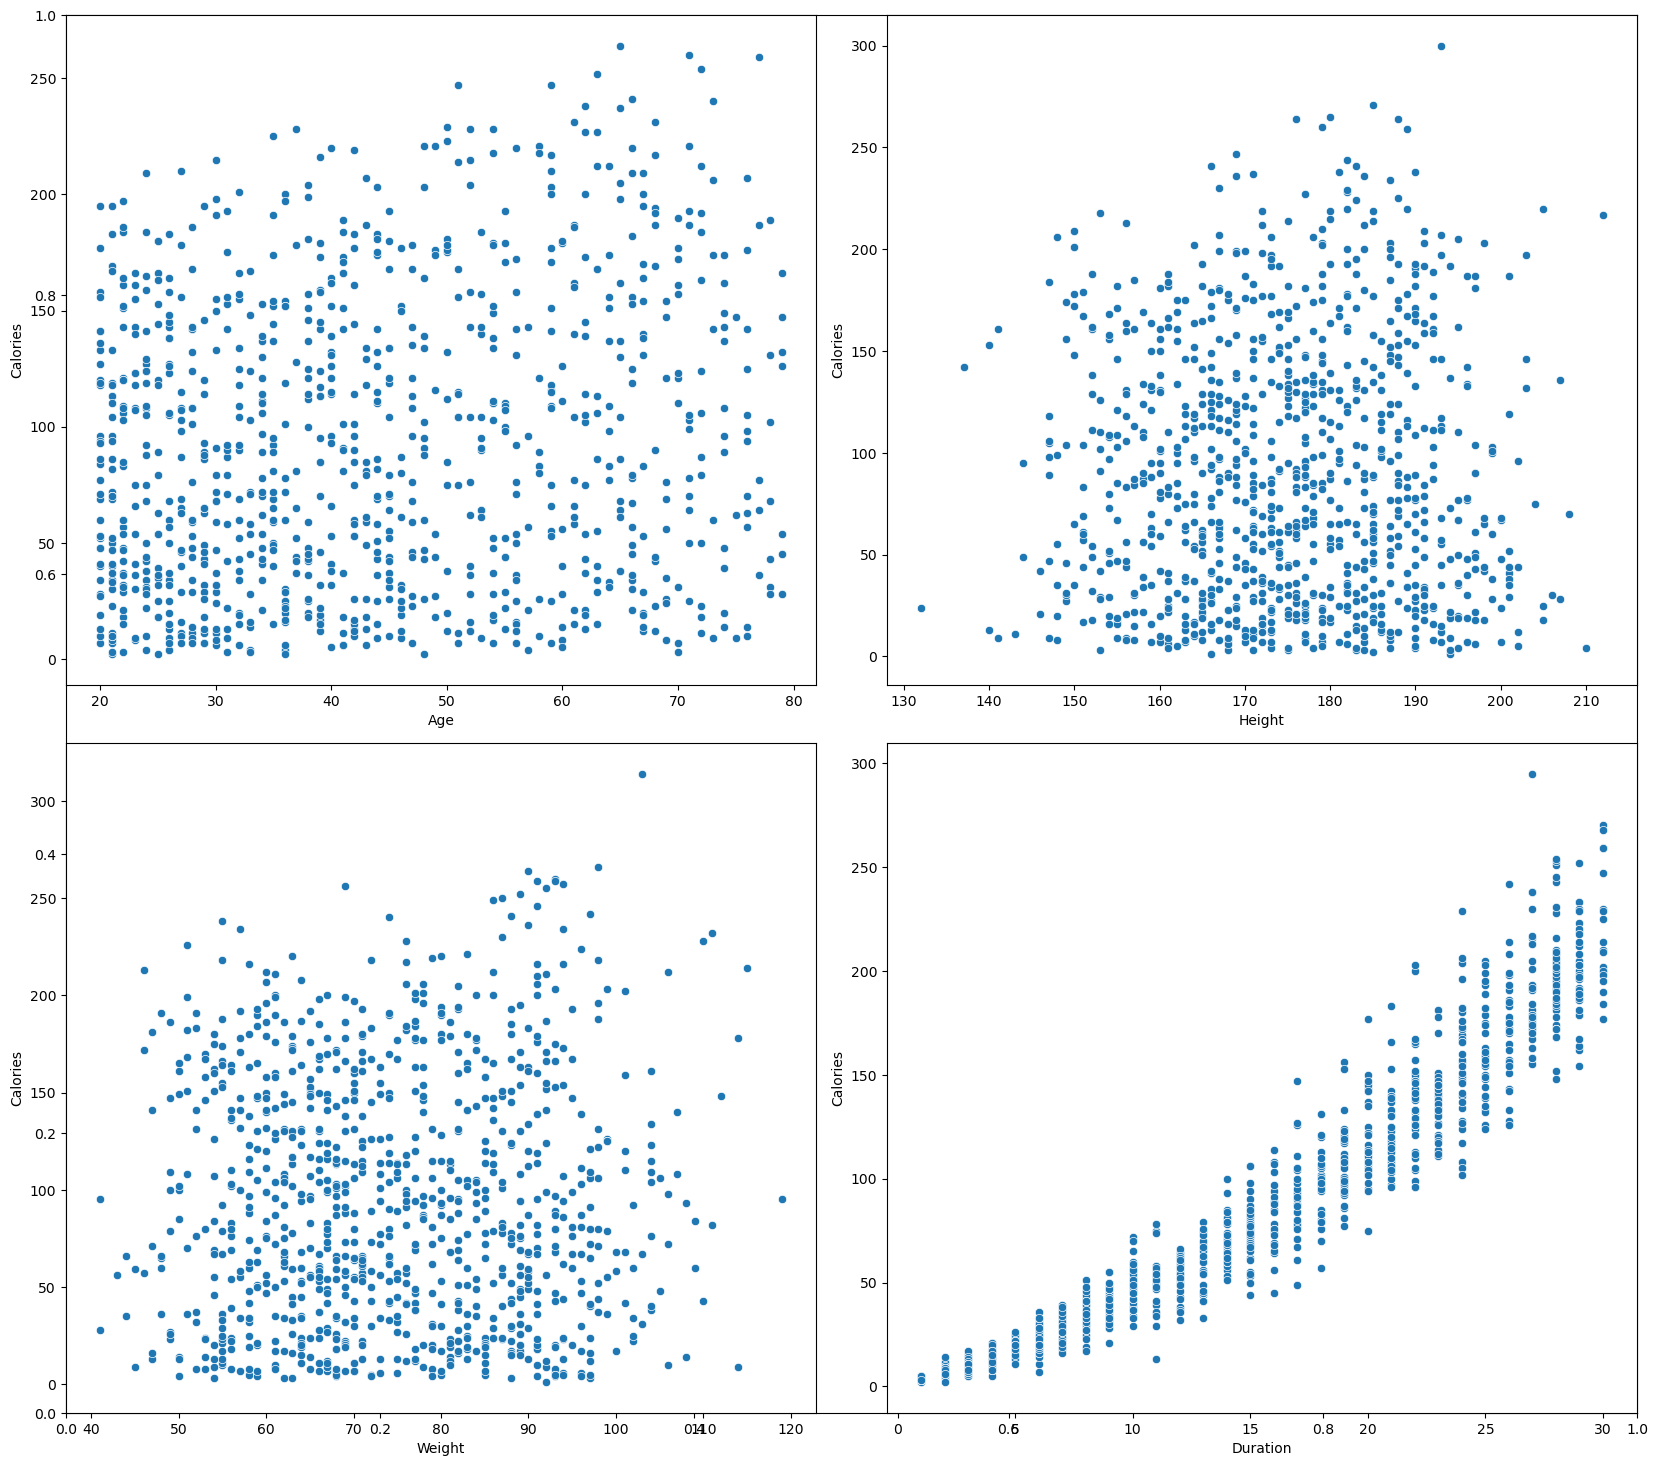

In [38]:
features=["Age","Height","Weight","Duration"]

plt.subplots(figsize=(17,15))
for i, cols in enumerate(features):
    plt.subplot(2,2,i+1)
    x=df.sample(1000)
    sns.scatterplot(x=cols,y='Calories',data=x)
    plt.tight_layout()
plt.show()


C:\Users\Sufiyan Asif\AppData\Local\Temp\ipykernel_6024\578002495.py:6: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df[col])
C:\Users\Sufiyan Asif\AppData\Local\Temp\ipykernel_6024\578002495.py:6: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df[col])
C:\Users\Sufiyan Asif\AppData\Local\Temp\i

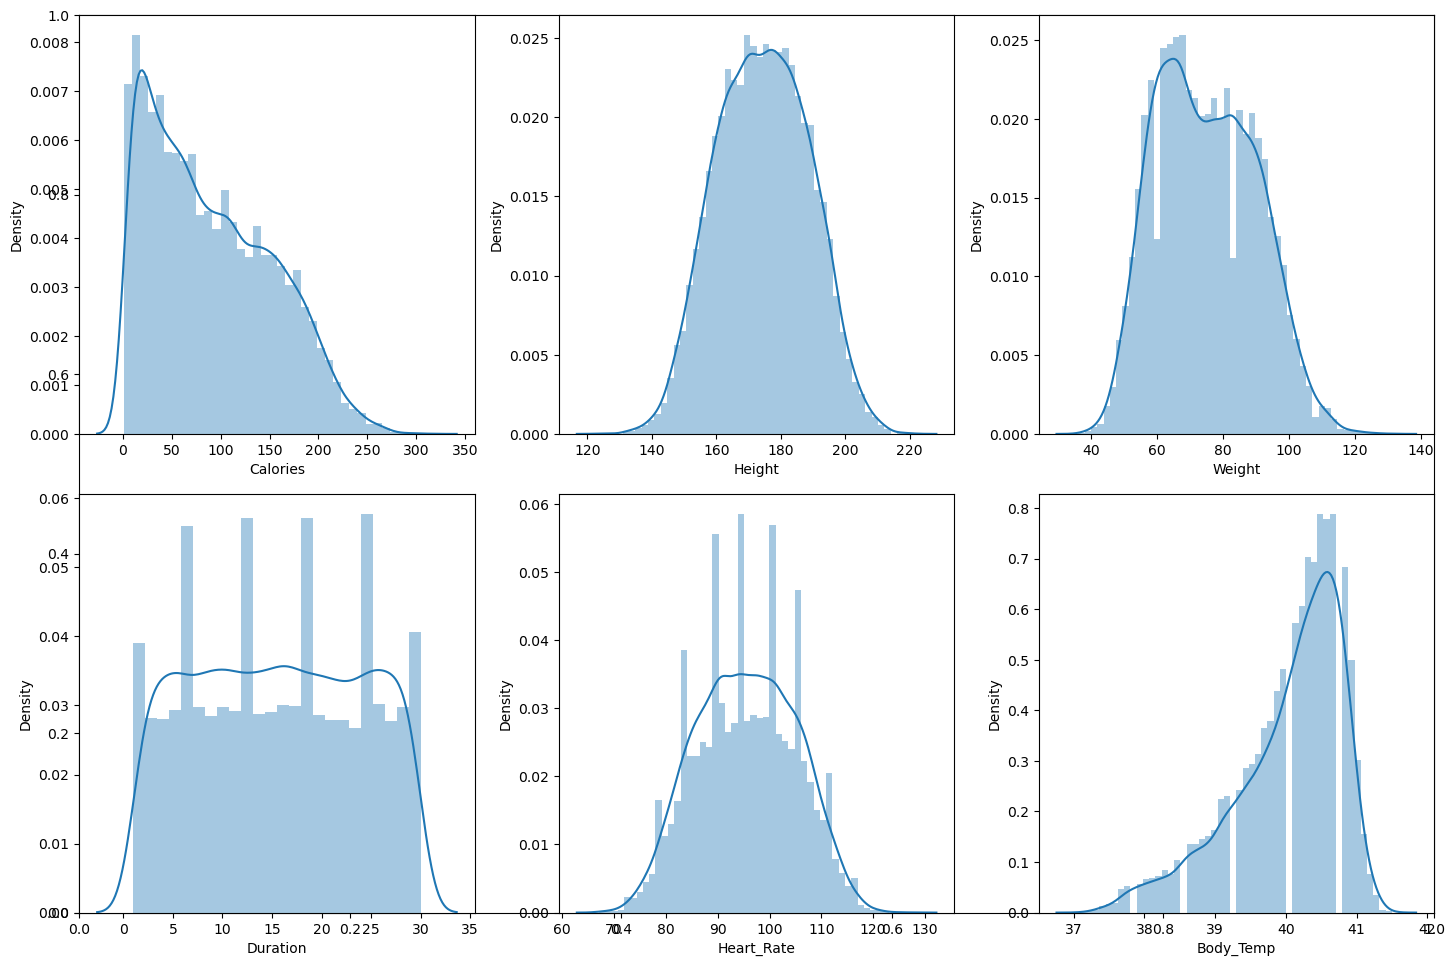

In [56]:
featurex = df.select_dtypes(include='float').columns

plt.subplots(figsize=(15, 10))
for i, col in enumerate(featurex):
    plt.subplot(2, 3, i + 1)
    sns.distplot(df[col])
plt.tight_layout()
plt.show()

In [58]:
df.replace({'male':1,'female':0},inplace=True)

C:\Users\Sufiyan Asif\AppData\Local\Temp\ipykernel_6024\2589789891.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df.replace({'male':1,'female':0},inplace=True)


In [59]:
df.head(5)

,User_ID,Calories,User_ID,Gender,Age,Height,Weight,Duration,Heart_Rate,Body_Temp
0,14733363,231.0,14733363,1,68,190.0,94.0,29.0,105.0,40.8
1,14861698,66.0,14861698,0,20,166.0,60.0,14.0,94.0,40.3
2,11179863,26.0,11179863,1,69,179.0,79.0,5.0,88.0,38.7
3,16180408,71.0,16180408,0,34,179.0,71.0,13.0,100.0,40.5
4,17771927,35.0,17771927,0,27,154.0,58.0,10.0,81.0,39.8


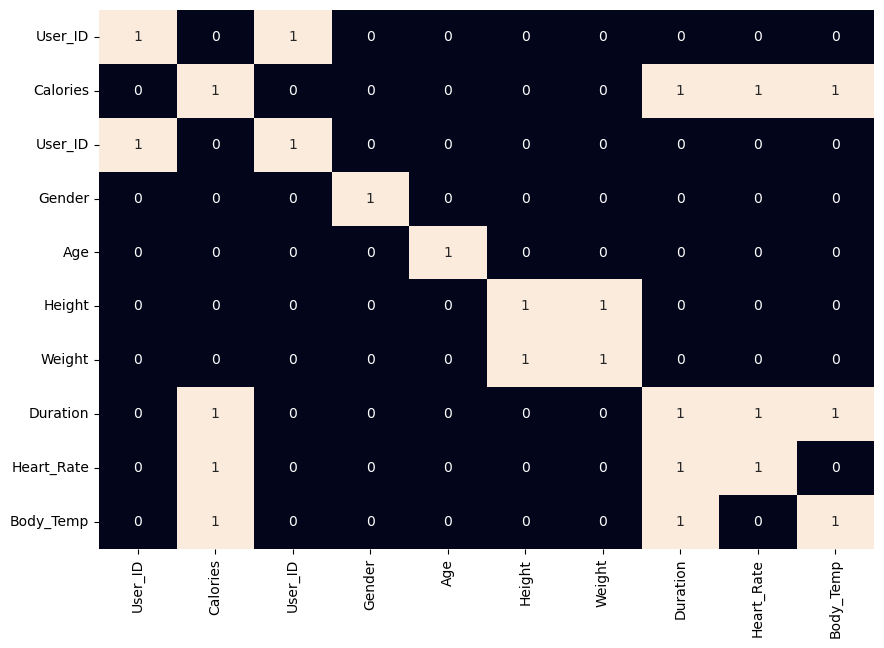

In [62]:
plt.figure(figsize=(10,7))
sns.heatmap(df.corr()>0.8,annot=True,cbar=False)
plt.show()

In [63]:
to_remove=["User_ID","Height","Heart_Rate","Duration"]
df.drop(to_remove,axis=1,inplace=True)

In [64]:
X=df.drop("Calories",axis=1)
y=df.Calories

In [65]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [68]:
X_train.shape, X_test.shape

((12000, 4), (3000, 4))

In [66]:
scaler=StandardScaler()

In [69]:
X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled=scaler.transform(X_test)

In [75]:
from sklearn.metrics import mean_absolute_error as mae
models=[LinearRegression(),Lasso(),Ridge(),XGBRegressor(),RandomForestRegressor()]
for i in range(5):
    models[i].fit(X_train,y_train)
    print("The Model is:",models[i])
    train_preds = models[i].predict(X_train)
    print('Training Error : ', mae(y_train, train_preds))

    val_preds = models[i].predict(X_test)
    print('Validation Error : ', mae(y_test, val_preds))
    print()
    

The Model is: LinearRegression()
Training Error :  27.30252450266684
Validation Error :  28.13184983050244

The Model is: Lasso()
Training Error :  27.348112643278846
Validation Error :  28.164682219656484

The Model is: Ridge()
Training Error :  27.30271393409019
Validation Error :  28.13198404676032

The Model is: XGBRegressor(base_score=0.5, booster='gbtree', callbacks=None,
             colsample_bylevel=1, colsample_bynode=1, colsample_bytree=1,
             early_stopping_rounds=None, enable_categorical=False,
             eval_metric=None, gamma=0, gpu_id=-1, grow_policy='depthwise',
             importance_type=None, interaction_constraints='',
             learning_rate=0.300000012, max_bin=256, max_cat_to_onehot=4,
             max_delta_step=0, max_depth=6, max_leaves=0, min_child_weight=1,
             missing=nan, monotone_constraints='()', n_estimators=100, n_jobs=0,
             num_parallel_tree=1, predictor='auto', random_state=0, reg_alpha=0,
             reg_lambda=1

In [77]:
RFG=RandomForestRegressor()
RFG.fit(X_train,y_train)

RandomForestRegressor()

In [90]:
y_pred=RFG.predict(X_test)

In [93]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [94]:
mse=mean_squared_error(y_test,y_pred)
mae=mean_absolute_error(y_test,y_pred)
r2=r2_score(y_test,y_pred)

In [100]:
print("MSE:", mse)
print("MAE:", mae)
print("R2 Score:", r2)

MSE: 836.0638206992659
MAE: 20.59201546031746
R2 Score: 0.7928377059630201
